C:\Users\tonid\AppData\Local\Temp\ipykernel_9136\769723436.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['p', 'P_L', 'ignore'])
C:\Users\tonid\AppData\Local\Temp\ipykernel_9136\769723436.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['p', 'P_L', 'ignore'])
C:\Users\tonid\AppData\Local\Temp\ipykernel_9136\769723436.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['p', 'P_L', 'ignore'])
C:\Users\tonid\AppData\Local\Temp\ipykernel_9136\769723436.py:32: FutureWarning: The 'delim

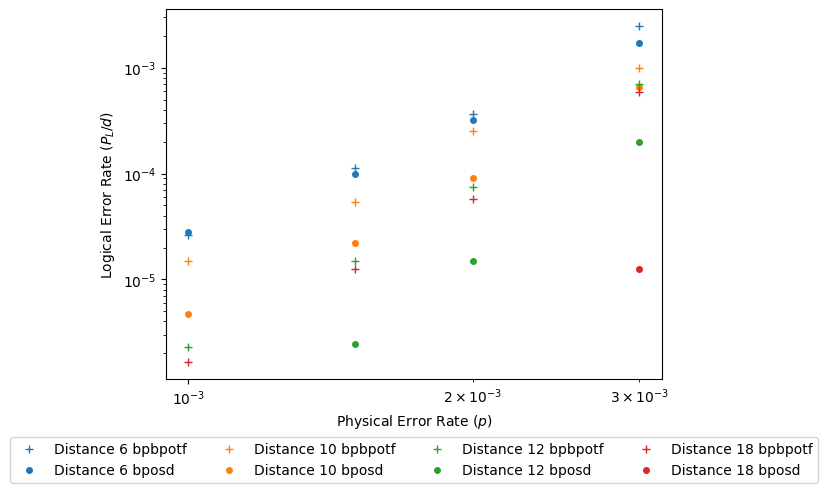

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Initialize a dictionary to store the data
data = {}

# Iterate over the files in the results folder
results_folder = 'results'
for filename in os.listdir(results_folder):
    if filename.startswith('bpbpotf_'):
        # Extract the distance from the filename
        distance = int(filename.split('_')[1].split('.')[0])
        # Read the file and extract the data
        filepath = os.path.join(results_folder, filename)
        df = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['p', 'P_L', 'ignore'])
        
        # Store the data in the dictionary
        data[distance] = df[['p', 'P_L']]

    # Initialize a dictionary to store the data for files starting with 'bposd_'
    data_bposd = {}

    # Iterate over the files in the results folder
    for filename in os.listdir(results_folder):
        if filename.startswith('bposd_'):
            # Extract the distance from the filename
            distance = int(filename.split('_')[1].split('.')[0])
            # Read the file and extract the data
            filepath = os.path.join(results_folder, filename)
            df = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['p', 'P_L', 'ignore'])
            
            # Store the data in the dictionary
            data_bposd[distance] = df[['p', 'P_L']]

# Plot the data
for distance in sorted(data.keys()):
    df = data[distance]
    
    
    plt.plot(df['p'], df['P_L'], '+', label=f'Distance {distance} bpbpotf')

    try:
        df = data_bposd[distance]
        plt.plot(df['p'], df['P_L'], 'o', markersize=4, label=f'Distance {distance} bposd', color=plt.gca().lines[-1].get_color())
    except KeyError:
        pass
    # Add a linear function spanning from the minimum to the maximum 'p'
    # p_min = min(df['p'])
    # p_max = max(df['p'])
    # p_values = [p_min, p_max]
    # P_L_values = [p_min, p_max]  # Linear function: P_L = p

    # plt.plot(p_values, P_L_values, label='Linear Function')

plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L/d$)')
plt.loglog()
plt.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.3))
# The data dictionary and plotting code are already present, no need to add anything here.
plt.show()